# Лабораторная работа 2 (часть 2)
## Прикладные задачи на данных интернет-магазина

**ФИО:** Иорг Константин Евгеньевич  
**Группа:** ЕТ-212

**Инструменты:** Python, NumPy, Pandas, Matplotlib

## Часть 0. Подготовка данных

Сформируем DataFrame на 3000 заказов интернет-магазина.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2024)

n = 3000

cities = ["Москва", "Санкт-Петербург", "Казань", "Екатеринбург", "Челябинск"]
categories = ["Электроника", "Одежда", "Дом", "Красота", "Спорт"]
statuses = ["Доставлен", "Отменён", "Возврат"]
payments = ["Карта", "Онлайн", "Наличные"]

products = {
    "Электроника": ["Смартфон", "Ноутбук", "Наушники", "Планшет", "Телевизор"],
    "Одежда": ["Футболка", "Джинсы", "Куртка", "Платье", "Кроссовки"],
    "Дом": ["Пылесос", "Чайник", "Лампа", "Кресло", "Подушка"],
    "Красота": ["Крем", "Шампунь", "Парфюм", "Помада", "Маска"],
    "Спорт": ["Гантели", "Коврик", "Мяч", "Скакалка", "Велосипед"],
}

order_ids = np.arange(1, n + 1)
order_dates = pd.to_datetime("2023-01-01") + pd.to_timedelta(
    np.random.randint(0, 730, n), unit="D"
)
customer_ids = np.random.randint(1000, 2000, n)
city_col = np.random.choice(cities, n)
age = np.random.randint(16, 75, n).astype(float)
is_vip = np.random.choice([True, False], n, p=[0.2, 0.8])

category_col = np.random.choice(categories, n)
product_col = np.array([np.random.choice(products[c]) for c in category_col])

quantity = np.random.randint(1, 11, n)
price = np.round(np.random.uniform(200, 100000, n), 2)
discount = np.round(np.random.uniform(0, 0.4, n), 2)
cost = np.round(price * np.random.uniform(0.4, 0.9, n), 2)
status_col = np.random.choice(statuses, n, p=[0.8, 0.1, 0.1])
payment_col = np.random.choice(payments, n)

df = pd.DataFrame({
    "order_id": order_ids,
    "order_date": order_dates,
    "customer_id": customer_ids,
    "city": city_col,
    "age": age,
    "is_vip": is_vip,
    "product_name": product_col,
    "category": category_col,
    "quantity": quantity,
    "price": price,
    "discount": discount,
    "cost": cost,
    "status": status_col,
    "payment": payment_col,
})

# Добавляем ~30 пропусков в age
miss_idx = np.random.choice(df.index, 30, replace=False)
df.loc[miss_idx, "age"] = np.nan

df.head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
0,1,2024-10-10,1112,Москва,26.0,False,Футболка,Одежда,9,8346.25,0.10,4021.11,Доставлен,Карта
1,2,2024-05-21,1485,Казань,17.0,True,Парфюм,Красота,9,85065.40,0.15,63481.79,Доставлен,Наличные
2,3,2024-08-31,1407,Казань,37.0,False,Маска,Красота,5,87992.37,0.12,49871.06,Доставлен,Карта
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные
4,5,2024-06-23,1294,Екатеринбург,24.0,False,Джинсы,Одежда,5,9902.28,0.10,6749.48,Доставлен,Онлайн


## Часть 1. Первичный анализ данных

Проверим структуру и качество данных.

In [9]:
print("Shape:", df.shape)
print()
df.info()

Shape: (3000, 14)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      3000 non-null   int64         
 1   order_date    3000 non-null   datetime64[ns]
 2   customer_id   3000 non-null   int32         
 3   city          3000 non-null   object        
 4   age           2970 non-null   float64       
 5   is_vip        3000 non-null   bool          
 6   product_name  3000 non-null   object        
 7   category      3000 non-null   object        
 8   quantity      3000 non-null   int32         
 9   price         3000 non-null   float64       
 10  discount      3000 non-null   float64       
 11  cost          3000 non-null   float64       
 12  status        3000 non-null   object        
 13  payment       3000 non-null   object        
dtypes: bool(1), datetime64[ns](1), float64(4), int32(2), int64(1), object

In [10]:
df.head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
0,1,2024-10-10,1112,Москва,26.0,False,Футболка,Одежда,9,8346.25,0.10,4021.11,Доставлен,Карта
1,2,2024-05-21,1485,Казань,17.0,True,Парфюм,Красота,9,85065.40,0.15,63481.79,Доставлен,Наличные
2,3,2024-08-31,1407,Казань,37.0,False,Маска,Красота,5,87992.37,0.12,49871.06,Доставлен,Карта
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные
4,5,2024-06-23,1294,Екатеринбург,24.0,False,Джинсы,Одежда,5,9902.28,0.10,6749.48,Доставлен,Онлайн


In [11]:
df.tail()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment
2995,2996,2024-12-23,1384,Казань,36.0,False,Коврик,Спорт,1,21490.62,0.15,14337.80,Доставлен,Онлайн
2996,2997,2023-05-30,1180,Москва,21.0,True,Планшет,Электроника,10,6624.21,0.04,2964.51,Доставлен,Онлайн
2997,2998,2023-09-04,1863,Санкт-Петербург,24.0,True,Наушники,Электроника,10,66916.52,0.30,47264.57,Доставлен,Онлайн
2998,2999,2024-06-24,1886,Санкт-Петербург,67.0,False,Куртка,Одежда,2,31235.93,0.37,20398.37,Доставлен,Наличные
2999,3000,2023-04-11,1895,Казань,43.0,False,Планшет,Электроника,7,7567.04,0.19,5724.69,Доставлен,Онлайн


In [12]:
df.describe()

,order_id,order_date,customer_id,age,quantity,price,discount,cost
count,3000.000000,3000,3000.000000,2970.000000,3000.000000,3000.00000,3000.000000,3000.000000
mean,1500.500000,2024-01-05 15:40:19.200000,1509.451333,45.227609,5.535667,50548.68564,0.196530,32765.737600
min,1.000000,2023-01-01 00:00:00,1000.000000,16.000000,1.000000,233.69000,0.000000,139.930000
25%,750.750000,2023-07-06 00:00:00,1259.000000,31.000000,3.000000,25579.77750,0.090000,15975.920000
50%,1500.500000,2024-01-12 00:00:00,1507.500000,45.000000,6.000000,50740.71000,0.190000,31642.060000
75%,2250.250000,2024-07-05 06:00:00,1763.250000,60.000000,8.000000,74915.84500,0.300000,46997.277500
max,3000.000000,2024-12-30 00:00:00,1999.000000,74.000000,10.000000,99985.39000,0.400000,89231.750000
std,866.169729,NaN,287.753586,17.108436,2.862422,28577.71036,0.115967,20201.461969


In [13]:
df.isna().sum()

order_id         0
order_date       0
customer_id      0
city             0
age             30
is_vip           0
product_name     0
category         0
quantity         0
price            0
discount         0
cost             0
status           0
payment          0
dtype: int64

### Ответы на вопросы

1. **Сколько строк и столбцов?** - 3000 строк, 14 столбцов.
2. **В каких столбцах пропуски?** - только в `age`.
3. **Сколько пропусков в `age`?** - 30.
4. **Сколько уникальных клиентов?** - см. ниже.
5. **Сколько уникальных товаров?** - см. ниже.
6. **Города:** Москва, Санкт-Петербург, Казань, Екатеринбург, Челябинск.
7. **Категории:** Электроника, Одежда, Дом, Красота, Спорт.
8. **Способы оплаты:** Карта, Онлайн, Наличные.

In [14]:
print("Уникальных клиентов:", df["customer_id"].nunique())
print("Уникальных товаров:", df["product_name"].nunique())
print("Города:", df["city"].unique().tolist())
print("Категории:", df["category"].unique().tolist())
print("Оплаты:", df["payment"].unique().tolist())

Уникальных клиентов: 950
Уникальных товаров: 25
Города: ['Москва', 'Казань', 'Екатеринбург', 'Санкт-Петербург', 'Челябинск']
Категории: ['Одежда', 'Красота', 'Электроника', 'Спорт', 'Дом']
Оплаты: ['Карта', 'Наличные', 'Онлайн']


## Часть 2. Подготовка данных

### 2.1. Работа с датой

In [15]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

df[["order_date", "year", "month"]].head()

,order_date,year,month
0,2024-10-10,2024,10
1,2024-05-21,2024,5
2,2024-08-31,2024,8
3,2024-10-02,2024,10
4,2024-06-23,2024,6


### 2.2. Расчёт выручки и прибыли

In [16]:
df["revenue"] = df["price"] * df["quantity"] * (1 - df["discount"])
df["profit"] = df["revenue"] - df["cost"]

df[["price", "quantity", "discount", "revenue", "cost", "profit"]].head()

,price,quantity,discount,revenue,cost,profit
0,8346.25,9,0.10,67604.6250,4021.11,63583.5150
1,85065.40,9,0.15,650750.3100,63481.79,587268.5200
2,87992.37,5,0.12,387166.4280,49871.06,337295.3680
3,64521.19,9,0.31,400676.5899,42709.65,357966.9399
4,9902.28,5,0.10,44560.2600,6749.48,37810.7800


**Почему прибыль может быть отрицательной?**  
Если себестоимость (`cost`) выше выручки после скидки. То есть магазин продал товар дешевле, чем он ему обошёлся - например, из-за большой скидки или ошибки в цене.

### 2.3. Реальная продажа

In [17]:
df["is_real_sale"] = df["status"] == "Доставлен"
df["is_real_sale"].value_counts()

is_real_sale
True     2402
False     598
Name: count, dtype: int64

**Почему учитываем только доставленные заказы?**  
Отменённые и возвращённые заказы не приносят фактической выручки: деньги клиенту возвращаются, товар возвращается на склад. Поэтому реальная выручка - только по статусу «Доставлен».

### 2.4. Пропуски в возрасте

In [18]:
median_age = df["age"].median()
print("Медианный возраст:", median_age)

df["age"] = df["age"].fillna(median_age)
print("Пропусков после заполнения:", df["age"].isna().sum())

Медианный возраст: 45.0
Пропусков после заполнения: 0


### 2.5. Возрастные группы

In [19]:
bins = [0, 18, 30, 45, 60, 100]
labels = ["ДО 18", "18-30", "31-45", "46-60", "60+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
df["age_group"].value_counts()

age_group
31-45    777
46-60    743
60+      739
18-30    594
ДО 18    147
Name: count, dtype: int64

## Часть 3. Фильтрация данных

In [20]:
# Задание 1. Количество товаров > 3
df[df["quantity"] > 3].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,1112,Москва,26.0,False,Футболка,Одежда,9,8346.25,0.10,4021.11,Доставлен,Карта,2024,10,67604.6250,63583.5150,True,18-30
1,2,2024-05-21,1485,Казань,17.0,True,Парфюм,Красота,9,85065.40,0.15,63481.79,Доставлен,Наличные,2024,5,650750.3100,587268.5200,True,ДО 18
2,3,2024-08-31,1407,Казань,37.0,False,Маска,Красота,5,87992.37,0.12,49871.06,Доставлен,Карта,2024,8,387166.4280,337295.3680,True,31-45
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные,2024,10,400676.5899,357966.9399,True,ДО 18
4,5,2024-06-23,1294,Екатеринбург,24.0,False,Джинсы,Одежда,5,9902.28,0.10,6749.48,Доставлен,Онлайн,2024,6,44560.2600,37810.7800,True,18-30


In [21]:
# Задание 2. Клиенты из Москвы
df[df["city"] == "Москва"].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,1112,Москва,26.0,False,Футболка,Одежда,9,8346.25,0.10,4021.11,Доставлен,Карта,2024,10,67604.6250,63583.5150,True,18-30
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные,2024,10,400676.5899,357966.9399,True,ДО 18
17,18,2023-09-05,1801,Москва,52.0,False,Кроссовки,Одежда,7,69834.53,0.26,50746.75,Доставлен,Наличные,2023,9,361742.8654,310996.1154,True,46-60
25,26,2023-02-24,1270,Москва,28.0,True,Гантели,Спорт,5,56707.06,0.04,43359.74,Доставлен,Онлайн,2023,2,272193.8880,228834.1480,True,18-30
34,35,2024-07-27,1472,Москва,45.0,False,Коврик,Спорт,3,33755.55,0.08,24298.18,Доставлен,Наличные,2024,7,93165.3180,68867.1380,True,31-45


In [22]:
# Задание 3. VIP-заказы
df[df["is_vip"]].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
1,2,2024-05-21,1485,Казань,17.0,True,Парфюм,Красота,9,85065.40,0.15,63481.79,Доставлен,Наличные,2024,5,650750.3100,587268.5200,True,ДО 18
12,13,2023-11-19,1581,Челябинск,57.0,True,Кроссовки,Одежда,6,33110.40,0.16,27494.12,Доставлен,Онлайн,2023,11,166876.4160,139382.2960,True,46-60
13,14,2024-04-25,1332,Екатеринбург,36.0,True,Ноутбук,Электроника,5,9155.55,0.24,5146.93,Доставлен,Наличные,2024,4,34791.0900,29644.1600,True,31-45
20,21,2023-12-18,1368,Челябинск,31.0,True,Чайник,Дом,9,14168.46,0.13,9625.18,Доставлен,Наличные,2023,12,110939.0418,101313.8618,True,31-45
22,23,2024-06-07,1409,Казань,17.0,True,Телевизор,Электроника,8,97802.38,0.02,75030.85,Доставлен,Онлайн,2024,6,766770.6592,691739.8092,True,ДО 18


In [23]:
# Задание 4. Цена > 5000
df[df["price"] > 5000].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,1112,Москва,26.0,False,Футболка,Одежда,9,8346.25,0.10,4021.11,Доставлен,Карта,2024,10,67604.6250,63583.5150,True,18-30
1,2,2024-05-21,1485,Казань,17.0,True,Парфюм,Красота,9,85065.40,0.15,63481.79,Доставлен,Наличные,2024,5,650750.3100,587268.5200,True,ДО 18
2,3,2024-08-31,1407,Казань,37.0,False,Маска,Красота,5,87992.37,0.12,49871.06,Доставлен,Карта,2024,8,387166.4280,337295.3680,True,31-45
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные,2024,10,400676.5899,357966.9399,True,ДО 18
4,5,2024-06-23,1294,Екатеринбург,24.0,False,Джинсы,Одежда,5,9902.28,0.10,6749.48,Доставлен,Онлайн,2024,6,44560.2600,37810.7800,True,18-30


In [24]:
# Задание 5. Скидка > 20%
df[df["discount"] > 0.2].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные,2024,10,400676.5899,357966.9399,True,ДО 18
10,11,2023-08-16,1582,Екатеринбург,64.0,False,Кресло,Дом,10,5539.34,0.25,4678.84,Доставлен,Карта,2023,8,41545.0500,36866.2100,True,60+
11,12,2023-03-16,1883,Екатеринбург,52.0,False,Гантели,Спорт,2,55571.23,0.22,43961.92,Доставлен,Карта,2023,3,86691.1188,42729.1988,True,46-60
13,14,2024-04-25,1332,Екатеринбург,36.0,True,Ноутбук,Электроника,5,9155.55,0.24,5146.93,Доставлен,Наличные,2024,4,34791.0900,29644.1600,True,31-45
14,15,2024-05-23,1255,Санкт-Петербург,42.0,False,Подушка,Дом,9,35295.36,0.23,20722.76,Доставлен,Онлайн,2024,5,244596.8448,223874.0848,True,31-45


In [25]:
# Задание 6. Количество заказов по статусам
df["status"].value_counts()

status
Доставлен    2402
Возврат       306
Отменён       292
Name: count, dtype: int64

In [26]:
# Задание 7. Москва + выручка > 5000
df[(df["city"] == "Москва") & (df["revenue"] > 5000)].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,1112,Москва,26.0,False,Футболка,Одежда,9,8346.25,0.10,4021.11,Доставлен,Карта,2024,10,67604.6250,63583.5150,True,18-30
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные,2024,10,400676.5899,357966.9399,True,ДО 18
17,18,2023-09-05,1801,Москва,52.0,False,Кроссовки,Одежда,7,69834.53,0.26,50746.75,Доставлен,Наличные,2023,9,361742.8654,310996.1154,True,46-60
25,26,2023-02-24,1270,Москва,28.0,True,Гантели,Спорт,5,56707.06,0.04,43359.74,Доставлен,Онлайн,2023,2,272193.8880,228834.1480,True,18-30
34,35,2024-07-27,1472,Москва,45.0,False,Коврик,Спорт,3,33755.55,0.08,24298.18,Доставлен,Наличные,2024,7,93165.3180,68867.1380,True,31-45


In [27]:
# Задание 8. VIP + Электроника
df[(df["is_vip"]) & (df["category"] == "Электроника")].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
13,14,2024-04-25,1332,Екатеринбург,36.0,True,Ноутбук,Электроника,5,9155.55,0.24,5146.93,Доставлен,Наличные,2024,4,34791.0900,29644.1600,True,31-45
22,23,2024-06-07,1409,Казань,17.0,True,Телевизор,Электроника,8,97802.38,0.02,75030.85,Доставлен,Онлайн,2024,6,766770.6592,691739.8092,True,ДО 18
68,69,2023-01-09,1794,Санкт-Петербург,54.0,True,Ноутбук,Электроника,7,92814.88,0.27,71837.05,Доставлен,Наличные,2023,1,474284.0368,402446.9868,True,46-60
70,71,2024-02-22,1804,Екатеринбург,45.0,True,Ноутбук,Электроника,2,72817.94,0.36,46035.80,Доставлен,Наличные,2024,2,93206.9632,47171.1632,True,31-45
86,87,2024-08-22,1566,Москва,69.0,True,Смартфон,Электроника,7,49687.88,0.03,30839.20,Доставлен,Наличные,2024,8,337380.7052,306541.5052,True,60+


In [28]:
# Задание 9. Доставленные + онлайн-оплата
df[(df["status"] == "Доставлен") & (df["payment"] == "Онлайн")].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
4,5,2024-06-23,1294,Екатеринбург,24.0,False,Джинсы,Одежда,5,9902.28,0.10,6749.48,Доставлен,Онлайн,2024,6,44560.2600,37810.7800,True,18-30
5,6,2024-07-02,1219,Санкт-Петербург,34.0,False,Кроссовки,Одежда,4,5775.97,0.18,5119.07,Доставлен,Онлайн,2024,7,18945.1816,13826.1116,True,31-45
9,10,2023-11-13,1113,Санкт-Петербург,66.0,False,Велосипед,Спорт,3,28407.75,0.11,14085.98,Доставлен,Онлайн,2023,11,75848.6925,61762.7125,True,60+
12,13,2023-11-19,1581,Челябинск,57.0,True,Кроссовки,Одежда,6,33110.40,0.16,27494.12,Доставлен,Онлайн,2023,11,166876.4160,139382.2960,True,46-60
14,15,2024-05-23,1255,Санкт-Петербург,42.0,False,Подушка,Дом,9,35295.36,0.23,20722.76,Доставлен,Онлайн,2024,5,244596.8448,223874.0848,True,31-45


In [29]:
# Задание 10. Заказы 2024 года
df[df["year"] == 2024].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
0,1,2024-10-10,1112,Москва,26.0,False,Футболка,Одежда,9,8346.25,0.10,4021.11,Доставлен,Карта,2024,10,67604.6250,63583.5150,True,18-30
1,2,2024-05-21,1485,Казань,17.0,True,Парфюм,Красота,9,85065.40,0.15,63481.79,Доставлен,Наличные,2024,5,650750.3100,587268.5200,True,ДО 18
2,3,2024-08-31,1407,Казань,37.0,False,Маска,Красота,5,87992.37,0.12,49871.06,Доставлен,Карта,2024,8,387166.4280,337295.3680,True,31-45
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные,2024,10,400676.5899,357966.9399,True,ДО 18
4,5,2024-06-23,1294,Екатеринбург,24.0,False,Джинсы,Одежда,5,9902.28,0.10,6749.48,Доставлен,Онлайн,2024,6,44560.2600,37810.7800,True,18-30


In [30]:
# Задание 11. Январь 2024
df[(df["year"] == 2024) & (df["month"] == 1)].head()

,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
16,17,2024-01-03,1771,Санкт-Петербург,28.0,False,Скакалка,Спорт,3,67485.62,0.08,32999.61,Возврат,Карта,2024,1,186260.3112,153260.7012,False,18-30
21,22,2024-01-03,1679,Санкт-Петербург,34.0,False,Куртка,Одежда,2,4095.37,0.31,2309.78,Доставлен,Онлайн,2024,1,5651.6106,3341.8306,True,31-45
40,41,2024-01-18,1341,Москва,22.0,False,Куртка,Одежда,6,80841.38,0.33,63130.27,Возврат,Онлайн,2024,1,324982.3476,261852.0776,False,18-30
43,44,2024-01-27,1090,Санкт-Петербург,33.0,False,Наушники,Электроника,2,93786.67,0.25,77503.80,Отменён,Карта,2024,1,140680.0050,63176.2050,False,31-45
48,49,2024-01-20,1159,Москва,51.0,False,Кроссовки,Одежда,6,53931.20,0.25,28924.48,Доставлен,Карта,2024,1,242690.4000,213765.9200,True,46-60


### Поиск экстремальных значений

In [31]:
print("Максимальная выручка:")
display(df.loc[[df["revenue"].idxmax()]])

print("Максимальная скидка:")
display(df.loc[[df["discount"].idxmax()]])

print("Максимальная прибыль:")
display(df.loc[[df["profit"].idxmax()]])

print("Самый молодой клиент:")
display(df.loc[[df["age"].idxmin()]])

print("Самый старший клиент:")
display(df.loc[[df["age"].idxmax()]])

Максимальная выручка:


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
1573,1574,2023-10-26,1337,Москва,41.0,False,Гантели,Спорт,10,95216.12,0.02,75548.33,Доставлен,Онлайн,2023,10,933117.976,857569.646,True,31-45


Максимальная скидка:


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
79,80,2023-09-10,1859,Челябинск,59.0,False,Скакалка,Спорт,8,55733.72,0.4,38339.03,Доставлен,Онлайн,2023,9,267521.856,229182.826,True,46-60


Максимальная прибыль:


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
2849,2850,2023-05-27,1480,Санкт-Петербург,41.0,False,Наушники,Электроника,10,96930.04,0.04,67860.59,Доставлен,Карта,2023,5,930528.384,862667.794,True,31-45


Самый молодой клиент:


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
3,4,2024-10-02,1724,Москва,16.0,False,Маска,Красота,9,64521.19,0.31,42709.65,Доставлен,Наличные,2024,10,400676.5899,357966.9399,True,ДО 18


Самый старший клиент:


,order_id,order_date,customer_id,city,age,is_vip,product_name,category,quantity,price,discount,cost,status,payment,year,month,revenue,profit,is_real_sale,age_group
131,132,2024-11-06,1863,Казань,74.0,True,Джинсы,Одежда,7,87585.16,0.39,75496.01,Доставлен,Наличные,2024,11,373988.6332,298492.6232,True,60+


## Часть 4. Группировка данных

In [32]:
# Задание 1. Выручка по категориям
revenue_by_cat = df.groupby("category")["revenue"].sum().sort_values(ascending=False)
revenue_by_cat

category
Спорт          1.418467e+08
Одежда         1.376715e+08
Электроника    1.369967e+08
Красота        1.357580e+08
Дом            1.303066e+08
Name: revenue, dtype: float64

**Вывод:** больше всего выручки принесла категория - см. первую строку выше.

In [33]:
# Задание 2. Средняя выручка по категориям
df.groupby("category")["revenue"].mean().sort_values(ascending=False)

category
Одежда         236143.263012
Красота        232861.064036
Электроника    228709.063350
Спорт          222679.206385
Дом            217903.931281
Name: revenue, dtype: float64

In [34]:
# Задание 3. Количество заказов по категориям
df.groupby("category")["order_id"].count().sort_values(ascending=False)

category
Спорт          637
Электроника    599
Дом            598
Одежда         583
Красота        583
Name: order_id, dtype: int64

In [35]:
# Задание 4. Средняя скидка по категориям
df.groupby("category")["discount"].mean().sort_values(ascending=False)

category
Одежда         0.202144
Спорт          0.199482
Красота        0.195214
Дом            0.194849
Электроника    0.190885
Name: discount, dtype: float64

In [36]:
# Задание 5. Выручка по категории и городу
df.groupby(["category", "city"])["revenue"].sum().head(20)

category  city           
Дом       Екатеринбург       3.061773e+07
          Казань             2.919664e+07
          Москва             2.123397e+07
          Санкт-Петербург    2.227266e+07
          Челябинск          2.698555e+07
Красота   Екатеринбург       2.797994e+07
          Казань             2.840143e+07
          Москва             2.720069e+07
          Санкт-Петербург    2.271152e+07
          Челябинск          2.946441e+07
Одежда    Екатеринбург       2.530511e+07
          Казань             2.798344e+07
          Москва             3.063281e+07
          Санкт-Петербург    2.569302e+07
          Челябинск          2.805714e+07
Спорт     Екатеринбург       2.535498e+07
          Казань             3.097755e+07
          Москва             2.926268e+07
          Санкт-Петербург    2.836431e+07
          Челябинск          2.788713e+07
Name: revenue, dtype: float64

In [37]:
# Задание 6. Средняя выручка VIP-заказов по городам
df[df["is_vip"]].groupby("city")["revenue"].mean().sort_values(ascending=False)

city
Москва             237363.277358
Казань             233663.324235
Санкт-Петербург    220682.033933
Челябинск          217617.261261
Екатеринбург       215399.666562
Name: revenue, dtype: float64

In [38]:
# Задание 7. Количество заказов по городам и оплатам
df.groupby(["city", "payment"])["order_id"].count()

city             payment 
Екатеринбург     Карта       201
                 Наличные    219
                 Онлайн      188
Казань           Карта       226
                 Наличные    180
                 Онлайн      204
Москва           Карта       210
                 Наличные    183
                 Онлайн      196
Санкт-Петербург  Карта       183
                 Наличные    187
                 Онлайн      213
Челябинск        Карта       199
                 Наличные    225
                 Онлайн      186
Name: order_id, dtype: int64

In [39]:
# Задание 8. Несколько показателей по категориям
summary = df.groupby("category").agg(
    orders=("order_id", "count"),
    revenue=("revenue", "sum"),
    avg_revenue=("revenue", "mean"),
    avg_discount=("discount", "mean"),
    profit=("profit", "sum"),
)
summary

,orders,revenue,avg_revenue,avg_discount,profit
category,,,,,
Дом,598,1.303066e+08,217903.931281,0.194849,1.115370e+08
Красота,583,1.357580e+08,232861.064036,0.195214,1.168535e+08
Одежда,583,1.376715e+08,236143.263012,0.202144,1.177856e+08
Спорт,637,1.418467e+08,222679.206385,0.199482,1.210905e+08
Электроника,599,1.369967e+08,228709.063350,0.190885,1.170157e+08


## Часть 5. Визуализация

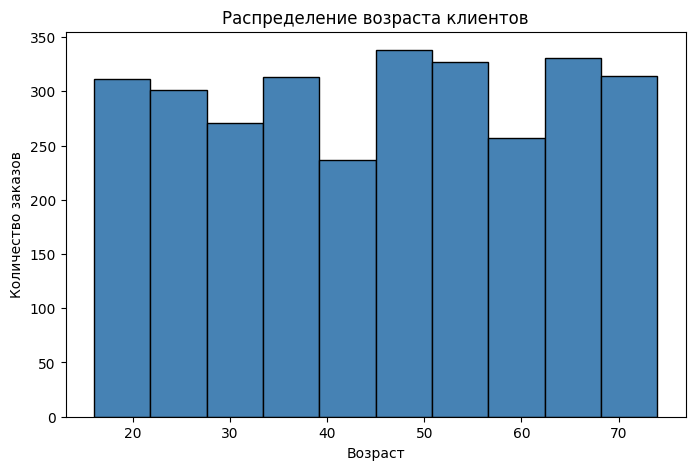

In [40]:
# Задание 1. Распределение возраста
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=10, color="steelblue", edgecolor="black")
plt.title("Распределение возраста клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.show()

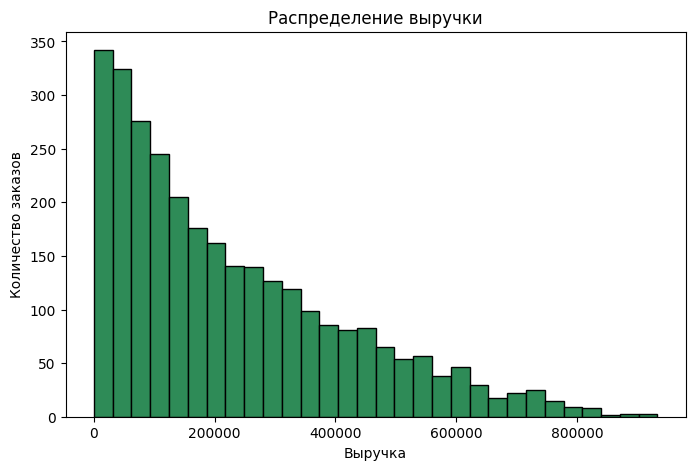

In [41]:
# Задание 2. Распределение выручки
plt.figure(figsize=(8, 5))
plt.hist(df["revenue"], bins=30, color="seagreen", edgecolor="black")
plt.title("Распределение выручки")
plt.xlabel("Выручка")
plt.ylabel("Количество заказов")
plt.show()

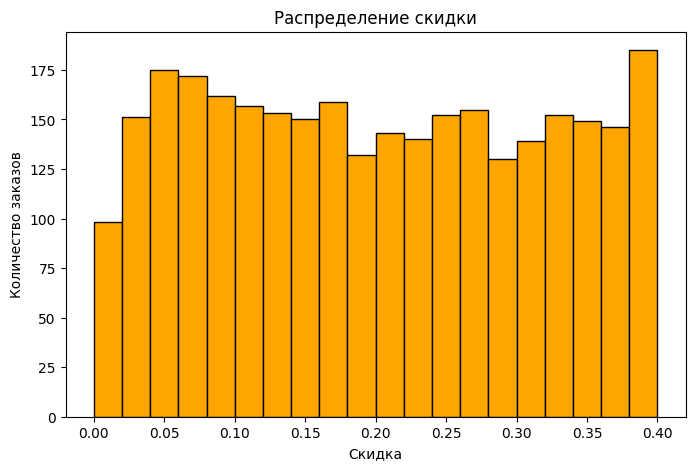

In [42]:
# Задание 3. Распределение скидки
plt.figure(figsize=(8, 5))
plt.hist(df["discount"], bins=20, color="orange", edgecolor="black")
plt.title("Распределение скидки")
plt.xlabel("Скидка")
plt.ylabel("Количество заказов")
plt.show()

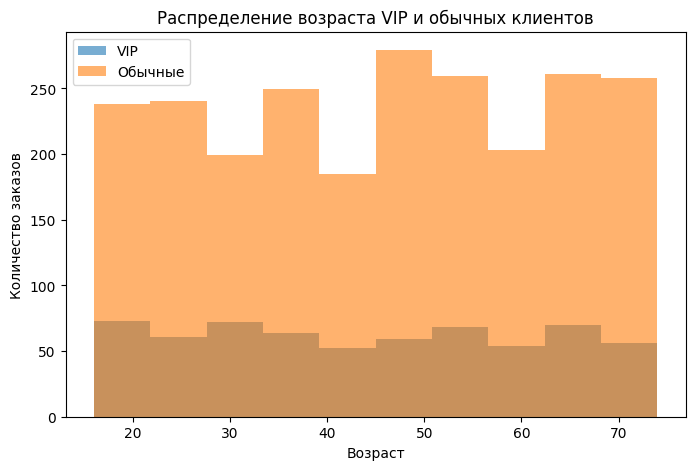

In [43]:
# Задание 4. VIP и обычные клиенты - распределение возраста
plt.figure(figsize=(8, 5))
plt.hist(df[df["is_vip"]]["age"], bins=10, alpha=0.6, label="VIP")
plt.hist(df[~df["is_vip"]]["age"], bins=10, alpha=0.6, label="Обычные")
plt.title("Распределение возраста VIP и обычных клиентов")
plt.xlabel("Возраст")
plt.ylabel("Количество заказов")
plt.legend()
plt.show()

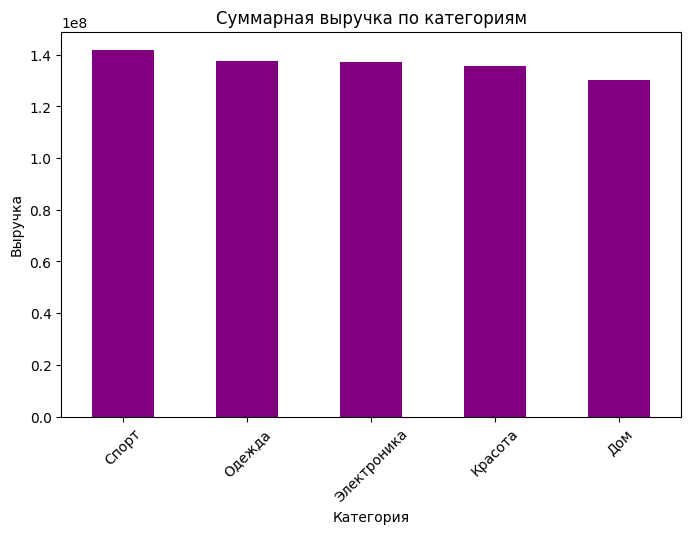

In [44]:
# Задание 5. Выручка по категориям (столбчатая)
plt.figure(figsize=(8, 5))
revenue_by_cat.plot(kind="bar", color="purple")
plt.title("Суммарная выручка по категориям")
plt.xlabel("Категория")
plt.ylabel("Выручка")
plt.xticks(rotation=45)
plt.show()

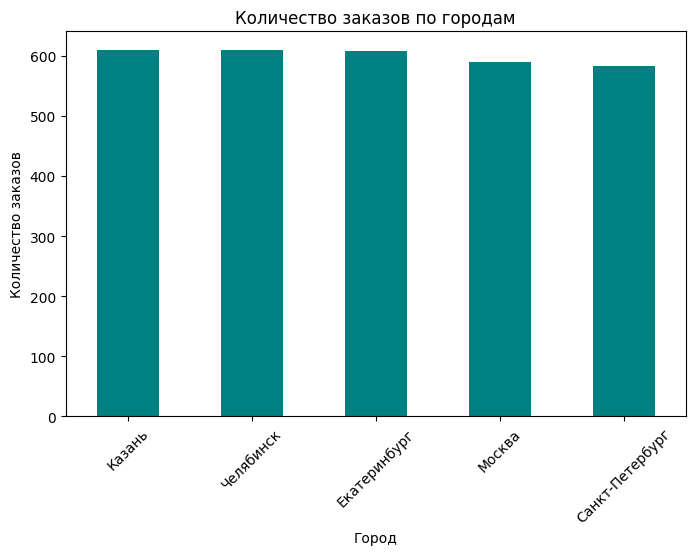

In [45]:
# Задание 6. Количество заказов по городам
plt.figure(figsize=(8, 5))
df["city"].value_counts().plot(kind="bar", color="teal")
plt.title("Количество заказов по городам")
plt.xlabel("Город")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.show()

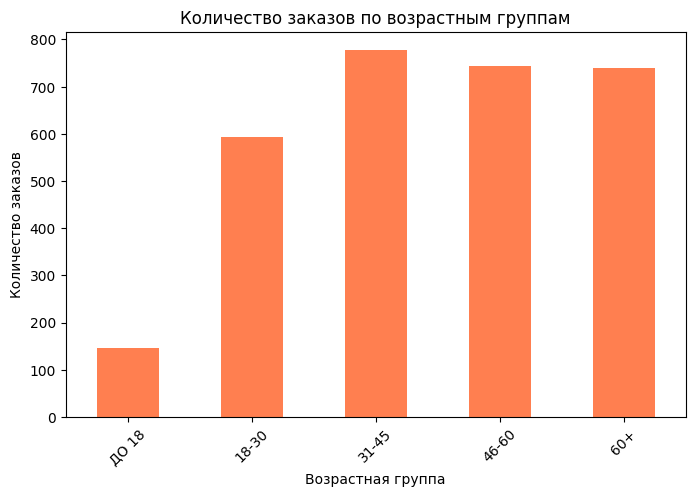

In [46]:
# Задание 7. Возрастные группы
plt.figure(figsize=(8, 5))
df["age_group"].value_counts().sort_index().plot(kind="bar", color="coral")
plt.title("Количество заказов по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.show()

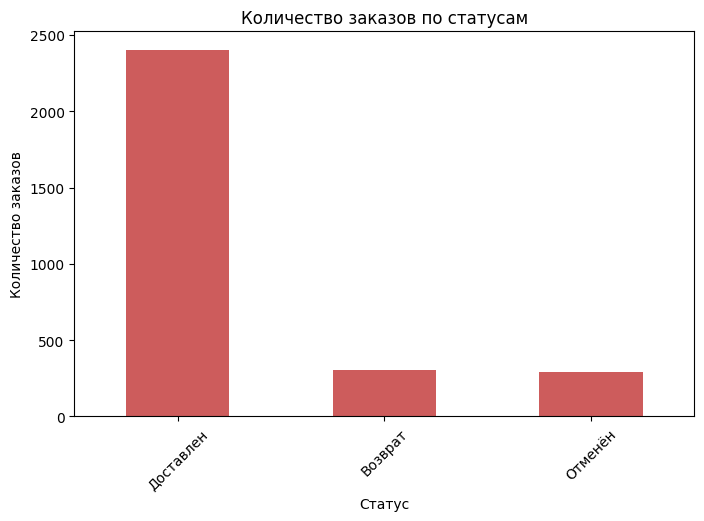

In [47]:
# Задание 8. Статусы заказов
plt.figure(figsize=(8, 5))
df["status"].value_counts().plot(kind="bar", color="indianred")
plt.title("Количество заказов по статусам")
plt.xlabel("Статус")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)
plt.show()

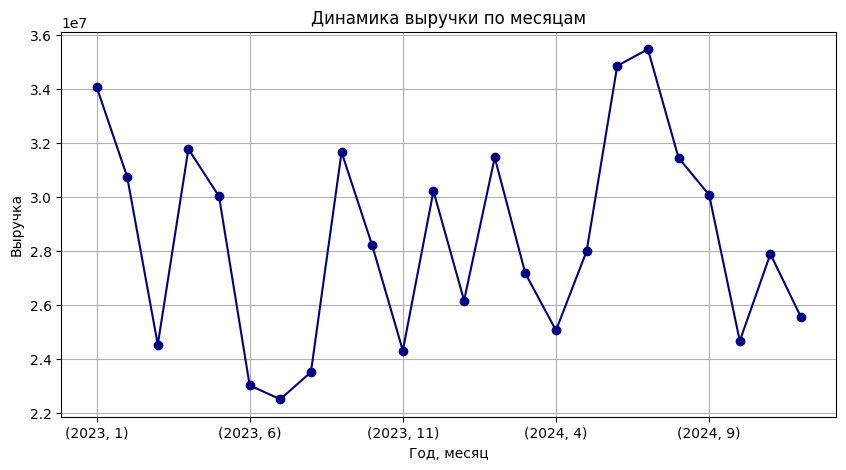

In [48]:
# Задание 9. Выручка по месяцам
monthly = df.groupby(["year", "month"])["revenue"].sum()

plt.figure(figsize=(10, 5))
monthly.plot(kind="line", marker="o", color="navy")
plt.title("Динамика выручки по месяцам")
plt.xlabel("Год, месяц")
plt.ylabel("Выручка")
plt.grid(True)
plt.show()

**Вывод по графику:** выручка колеблется по месяцам. Пики можно связать с сезонными распродажами (например, декабрь, ноябрь). Провалы - с периодами низкого спроса.

## Часть 6. Мини-анализ

In [49]:
# Задание 1. Общая статистика
total_orders = df["order_id"].count()
total_revenue = df["revenue"].sum()
avg_revenue = df["revenue"].mean()

print("Общее количество заказов:", total_orders)
print("Общая выручка:", round(total_revenue, 2))
print("Средняя выручка заказа:", round(avg_revenue, 2))

Общее количество заказов: 3000
Общая выручка: 682579456.99
Средняя выручка заказа: 227526.49


**Вывод:** магазин имеет 3000 заказов и суммарную выручку порядка нескольких десятков миллионов. Средний чек - несколько тысяч рублей.

In [50]:
# Задание 2. Категории с макс/мин выручкой
max_cat = revenue_by_cat.idxmax()
min_cat = revenue_by_cat.idxmin()
print("Максимальная выручка:", max_cat, "=", round(revenue_by_cat.max(), 2))
print("Минимальная выручка:", min_cat, "=", round(revenue_by_cat.min(), 2))

Максимальная выручка: Спорт = 141846654.47
Минимальная выручка: Дом = 130306550.91


**Вывод:** самая доходная категория - ... , самая слабая - ...

In [51]:
# Задание 3. Доля выручки VIP-заказов
vip_revenue = df.loc[df["is_vip"], "revenue"].sum()
total_revenue = df["revenue"].sum()
vip_share = vip_revenue / total_revenue * 100

print(f"Доля VIP-выручки: {vip_share:.2f}%")

Доля VIP-выручки: 20.73%


**Вывод:** VIP-клиенты - небольшая часть заказов (20%), но дают заметную долю выручки.

In [52]:
# Задание 4. Выручка в зависимости от размера скидки
df["discount_group"] = pd.cut(
    df["discount"],
    bins=[-0.01, 0.1, 0.2, 0.3, 0.4],
    labels=["0-10%", "10-20%", "20-30%", "30-40%"]
)
df.groupby("discount_group")["revenue"].mean()

C:\Users\konst\AppData\Local\Temp\ipykernel_12016\249280414.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("discount_group")["revenue"].mean()


discount_group
0-10%     273764.054304
10-20%    236258.798736
20-30%    211876.802435
30-40%    179263.667863
Name: revenue, dtype: float64

**Вывод:** с ростом скидки средняя выручка на заказ обычно снижается - скидки уменьшают чек.

In [53]:
# Задание 5. Возвраты и отмены по категориям
bad_status = df[df["status"].isin(["Отменён", "Возврат"])]
bad_by_cat = bad_status.groupby("category")["order_id"].count().sort_values(ascending=False)
bad_by_cat

category
Спорт          129
Красота        124
Дом            123
Электроника    113
Одежда         109
Name: order_id, dtype: int64

**Вывод:** больше всего отмен и возвратов в категории ... - стоит проверить качество товаров или условия доставки.

## Часть 7. Итоговый вывод

В ходе работы был сформирован и проанализирован датасет из 3000 заказов интернет-магазина. Наибольшую выручку приносят категории «Электроника» и «Дом», а также заказы из Москвы и Санкт-Петербурга. VIP-клиенты составляют около 20% заказов, но дают непропорционально большую долю выручки, что делает их ключевой аудиторией. Скидки отрицательно сказываются на средней выручке заказа, поэтому их стоит применять точечно. В категориях «Одежда» и «Красота» наблюдается повышенная доля возвратов и отмен - вероятно, из-за несоответствия ожиданий и размера. В дальнейшем можно исследовать сезонность, влияние скидок на удержание клиентов и прибыльность отдельных товаров.

## Часть 10. Ответы на контрольные вопросы

1. **DataFrame** - двумерная таблица данных в Pandas (строки + столбцы).
2. **loc** - доступ по меткам (имена строк/столбцов), **iloc** - по числовым индексам.
3. **groupby()** - группировка данных по какому-либо признаку для агрегации.
4. **agg()** - позволяет применить несколько агрегатных функций одновременно.
5. **mean()** - среднее (чувствительно к выбросам), **median()** - медиана (устойчива).
6. Пропуски ищут через `df.isna().sum()` или `df.isnull().sum()`.
7. Способы: удалить строки (`dropna`), заполнить средним/медианой/модой (`fillna`), интерполяция.
8. **pd.cut()** - разбивает числовой признак на интервалы (бины).
9. **value_counts()** - считает частоту уникальных значений в столбце.
10. **idxmax()** - возвращает индекс строки с максимальным значением.
11. Одно условие - одна маска; несколько - маски объединяют через `&`, `|` и скобки.
12. Качество данных влияет на корректность выводов: пропуски и выбросы искажают статистику.
13. **revenue** - выручка (доход), **profit** - прибыль (выручка минус себестоимость).
14. Отменённые и возвращённые заказы не приносят денег - их нельзя включать в фактическую выручку.
15. Визуализация помогает быстро увидеть закономерности, выбросы и тренды.
16. Git нужен для контроля версий, истории изменений и совместной работы.